Loading necessary packages

In [ ]:
!pip install netCDF4
!pip install h5netcdf

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy.stats import linregress
from scipy.stats import pearsonr
import xarray as xr
import os
import glob
from scipy.stats import chi2_contingency, f_oneway,pearsonr
import matplotlib.pyplot as plt
import scipy.stats as stats

# Tick Range Data

Data was extracted using tigerline census beueau files and overlaying range maps to classify counties as 0,1,2 absent, reported or established. Data was then wrangled into one single dataframe with all 3 years.

1996

In [3]:
# Read in extracted data
df = pd.read_csv("1996TickRangeData.csv")

In [5]:
# wrangling step 1: Create new column to categorize the numeric values 
range_map = {
    0: 'No records', 
    1: 'Reported', 
    2: 'Established'
}
range1996 = df
range1996['STATUS'] = range1996['MAX'].map(range_map)
range1996['YEAR'] = 1996

In [7]:
# Wrangling step 2: rename columns
range1996.rename(columns = {'NAME':'COUNTY', 'MAX':'tick_value'}, inplace = True)
range1996

,COUNTY,tick_value,STATUS,YEAR
0,Beltrami,1,Reported,1996
1,Clearwater,1,Reported,1996
2,Lake of the Woods,1,Reported,1996
3,Roseau,1,Reported,1996
4,Marshall,1,Reported,1996
...,...,...,...,...
82,Kandiyohi,0,No records,1996
83,Pipestone,0,No records,1996
84,Renville,0,No records,1996
85,Cass,0,No records,1996


2016

In [9]:
# Read in extracted data and wrangling step 1: Create new column to categorize the numeric values 
range2015 = pd.read_csv('2016RangeData.csv')
range2015['STATUS'] = range2015['tick_value'].map(range_map)
range2015['YEAR'] = 2015
range2015.rename(columns = {'County':'COUNTY'}, inplace = True)
range2015

,tick_value,COUNTY,STATUS,YEAR
0,2,Lake of the Woods,Established,2015
1,2,Roseau,Established,2015
2,2,Koochiching,Established,2015
3,2,Beltrami,Established,2015
4,2,St. Louis,Established,2015
...,...,...,...,...
82,0,Dodge,No records,2015
83,0,Freeborn,No records,2015
84,0,Pipestone,No records,2015
85,0,Renville,No records,2015


2024 - from the CDC directly, not extracted from maps

In [11]:
# Read in data
df = pd.read_csv('CDCrange.csv')
df.head()

,FIPSCode,State,County,Ixodes_scapularis_County_Status,Ixodes_scapularis_data_source,Ixodes_pacificus_county_status,Ixodes_pacificus_data_source
0,1001,AL,Autauga County,Established,CDC ArboNET Tick Module historic data,No records,CDC ArboNET Tick Module historic data
1,1003,AL,Baldwin County,Established,CDC ArboNET Tick Module historic data,No records,CDC ArboNET Tick Module historic data
2,1005,AL,Barbour County,Established,CDC ArboNET Tick Module historic data,No records,CDC ArboNET Tick Module historic data
3,1007,AL,Bibb County,Established,CDC ArboNET Tick Module historic data,No records,CDC ArboNET Tick Module historic data
4,1009,AL,Blount County,No records,CDC ArboNET Tick Module historic data,No records,CDC ArboNET Tick Module historic data


In [13]:
# Wrangling step 1: Filtering for Minnesota only
range2024 = df[df.State == 'MN']
len(range2024)

87

In [15]:
# Wrangling step 2: dropping columns
columns_range_2024 = ['County', 'Ixodes_scapularis_County_Status']
range2024 = range2024[columns_range_2024]


In [17]:
# Wrangling step 3: adding numeric column
opposite_map = {
    'Established': 2, 
    'Reported' : 1, 
    'No records' : 0
}
range2024['tick_value'] = range2024['Ixodes_scapularis_County_Status'].map(opposite_map)
range2024['YEAR'] = 2024

In [19]:
# Wrangling step 4: rename column
range2024.rename(columns = {'Ixodes_scapularis_County_Status':'STATUS', 'County':'COUNTY'}, inplace = True)
range2024 = range2024.reset_index(drop = True)

In [21]:
# Wrangling Step 5: remove " County" after ever county to match 1996 and 2016 dataframes
range2024['COUNTY'] = range2024['COUNTY'].str.replace(r'\s*County\s*', '', regex=True)
range2024.to_csv('2024TickRangeData.csv', index=False)

In [23]:
# Combine into one tick range table, in long format
df_merged = range1996.merge(range2015, on='COUNTY', how='outer')
df_merged = df_merged.merge(range2024, on='COUNTY', how='outer')

df_merged.head()

,COUNTY,tick_value_x,STATUS_x,YEAR_x,tick_value_y,STATUS_y,YEAR_y,STATUS,tick_value,YEAR
0,Aitkin,1,Reported,1996,2,Established,2015,Established,2,2024
1,Anoka,2,Established,1996,2,Established,2015,Established,2,2024
2,Becker,0,No records,1996,2,Established,2015,Established,2,2024
3,Beltrami,1,Reported,1996,2,Established,2015,Established,2,2024
4,Benton,2,Established,1996,2,Established,2015,Established,2,2024


In [25]:
# Rename columns
merged_columns = {'tick_value_x': 'VALUE_1996', 'tick_value_y': 'VALUE_2015', 'tick_value': 'VALUE_2024',
                  'STATUS_x': 'STATUS_1996', 'STATUS_y': 'STATUS_2015', 'STATUS': 'STATUS_2024',
                  'YEAR_x': 'YEAR_1996', 'YEAR_y': 'YEAR_2015', 'YEAR': 'YEAR_2024'}
df_merged.rename(columns = merged_columns, inplace = True)
df_merged.to_csv('TickRange.csv', index = False)
df_merged.head()

,COUNTY,VALUE_1996,STATUS_1996,YEAR_1996,VALUE_2015,STATUS_2015,YEAR_2015,STATUS_2024,VALUE_2024,YEAR_2024
0,Aitkin,1,Reported,1996,2,Established,2015,Established,2,2024
1,Anoka,2,Established,1996,2,Established,2015,Established,2,2024
2,Becker,0,No records,1996,2,Established,2015,Established,2,2024
3,Beltrami,1,Reported,1996,2,Established,2015,Established,2,2024
4,Benton,2,Established,1996,2,Established,2015,Established,2,2024


# Tick-Borne Disease incidence per state 

Dataset was created via annual summary of infectious notifiiable diseases from the CDC. Data was wrangled to include only Minnesota.

In [27]:
# Read in the data
tbd = pd.read_csv("TBDprevealence.csv")
tbd.head()

,Year,State,Total Population (in thousands),Anaplasmosis,Ehrlichiosis,Undetermined E/A,Babesiosis,Lyme disease
0,1996.0,MN,4658.0,NaN,NaN,NaN,NaN,251.0
1,1997.0,MN,4686.0,NaN,NaN,NaN,NaN,256.0
2,1998.0,MN,4725.0,NaN,NaN,NaN,NaN,261.0
3,1999.0,MN,4776.0,NaN,0.0,NaN,NaN,283.0
4,2000.0,MN,4776.0,NaN,83.0,NaN,NaN,465.0


In [29]:
# Filter for Minnesota 
tbd = tbd[tbd.State == 'MN']
tbd.to_csv('TBDprevealence.csv', index = False)
tbd.head()

,Year,State,Total Population (in thousands),Anaplasmosis,Ehrlichiosis,Undetermined E/A,Babesiosis,Lyme disease
0,1996.0,MN,4658.0,NaN,NaN,NaN,NaN,251.0
1,1997.0,MN,4686.0,NaN,NaN,NaN,NaN,256.0
2,1998.0,MN,4725.0,NaN,NaN,NaN,NaN,261.0
3,1999.0,MN,4776.0,NaN,0.0,NaN,NaN,283.0
4,2000.0,MN,4776.0,NaN,83.0,NaN,NaN,465.0


# Weather Data

Data from NOAA global summary of the month. Data wrangled for winter months in Minnesota for variables of interest. 

In [31]:
# Read in the dataframe
df = pd.read_csv("PastWeatherData.csv")
df.head()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,DSND,DSND_ATTRIBUTES,DT00,DT00_ATTRIBUTES,...,EMSN,EMSN_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,USC00212543,"ELY, MN US",47.9239,-91.8586,421.2,1997-11,NaN,NaN,3.0,",0",...,191.0,",,0,22,",438.0,",,,0",-4.9,",0",-0.9,",,,0",-8.8,",,,0"
1,USC00212543,"ELY, MN US",47.9239,-91.8586,421.2,1997-12,NaN,NaN,4.0,",0",...,38.0,",,0,04,",168.0,",,,0",-6.2,",0",-1.9,",,,0",-10.4,",,,0"
2,USC00212543,"ELY, MN US",47.9239,-91.8586,421.2,1998-01,NaN,NaN,10.0,",0",...,76.0,",,0,10,",276.0,",,,0",-10.6,"1,0",-5.9,"1,,,0",-15.2,",,,0"
3,USC00212543,"ELY, MN US",47.9239,-91.8586,421.2,1998-02,NaN,NaN,4.0,",0",...,20.0,",,0,02,",36.0,",,,0",-2.6,",0",2.3,",,,0",-7.5,",,,0"
4,USC00212543,"ELY, MN US",47.9239,-91.8586,421.2,1998-03,3.0,"5,0",6.0,",0",...,28.0,",,0,30,",102.0,",,,0",-4.1,",0",2.4,",,,0",-10.6,",,,0"


In [33]:
# Wrangle the data step 1: Get rid of the attribute columns
columns = ["STATION", "NAME", "LATITUDE", "LONGITUDE", "DATE", "DSND", "DT00", "EMNT", "EMSD", "EMSN", "SNOW", "TAVG", "TMAX", "TMIN"]
df = df[columns]
# DSND = days snow is greater than 1 in
# DT00 = days temp below 0 F
# EMNT = extreme min temp (C)
# EMSD = extreme max snow depth (mm)
# EMSN = extreme max snowfall 
# SNOW = total monthly snowfall (mm)

#convert my date columns to month and year 
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month
df = df.drop(columns=['DATE'])

In [35]:
# Wrangling step 2: mapping the points to counties
geometry = [Point(xy) for xy in zip(df['LONGITUDE'], df['LATITUDE'])] # Converts long and lat into points for mapping

In [37]:
gdf_stations = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [39]:
#Loads the county shapefile - using census tigerline file 

counties = gpd.read_file("tl_2025_us_county/tl_2025_us_county.shp")
counties = counties[['NAME','geometry', 'STATEFP']].rename(columns={'NAME':'county_name'})
counties = counties.to_crs("EPSG:4326")

In [41]:
# Drop index_right in case it exists
if 'index_right' in gdf_stations.columns:
    gdf_stations = gdf_stations.drop(columns=['index_right'])

# Spatial join
gdf_stations = gpd.sjoin(
    gdf_stations,
    counties,
    how='left',
    predicate='within'
)

# Drop the automatically added index_right column
if 'index_right' in gdf_stations.columns:
    gdf_stations = gdf_stations.drop(columns=['index_right'])


In [43]:
# Copy county_name column to the original df
df['COUNTY'] = gdf_stations['county_name']
df['STATEFP'] = gdf_stations['STATEFP']

In [44]:
# Wrangling step 3: get just the winter months
winter = [11, 12, 1, 2, 3] # ticks are active april-sept

winter_df = df[(df['MONTH'].isin(winter)) & (df['YEAR'] > 1985) & (df['STATEFP'] == '27')].copy()

winter_df.head()

,STATION,NAME,LATITUDE,LONGITUDE,DSND,DT00,EMNT,EMSD,EMSN,SNOW,TAVG,TMAX,TMIN,YEAR,MONTH,COUNTY,STATEFP
0,USC00212543,"ELY, MN US",47.9239,-91.8586,NaN,3.0,-26.7,NaN,191.0,438.0,-4.9,-0.9,-8.8,1997,11,St. Louis,27
1,USC00212543,"ELY, MN US",47.9239,-91.8586,NaN,4.0,-29.4,NaN,38.0,168.0,-6.2,-1.9,-10.4,1997,12,St. Louis,27
2,USC00212543,"ELY, MN US",47.9239,-91.8586,NaN,10.0,-31.1,NaN,76.0,276.0,-10.6,-5.9,-15.2,1998,1,St. Louis,27
3,USC00212543,"ELY, MN US",47.9239,-91.8586,NaN,4.0,-23.9,NaN,20.0,36.0,-2.6,2.3,-7.5,1998,2,St. Louis,27
4,USC00212543,"ELY, MN US",47.9239,-91.8586,3.0,6.0,-21.7,51.0,28.0,102.0,-4.1,2.4,-10.6,1998,3,St. Louis,27


In [47]:
# Aggregation: Group by county, YEAR, MONTH and aggregate
county_df = winter_df.groupby(['COUNTY','YEAR','MONTH']).agg({
    'EMNT':'mean',     # average extreme minimum across the county
    'EMSD':'mean',     # average extreme max snow depth across the county
    'TAVG':'mean',     # average temperature across the county
    'TMIN':'mean',     # average min temp across the county
    'TMAX':'mean',     # average max temp across the county
    'SNOW':'mean',     # average snowfall across the county
    'DT00':'mean',     # average days below 0 C across the county
    'DSND':'mean'      # average days snowfall is over 1 in across the county
}).reset_index()


In [48]:
# Removes Jan, Feb and Mar from 1995 as they are not needed
county_df = county_df.iloc[3:].copy()

In [ ]:
county_df.to_csv('NOAA_weather_data.csv')

In [51]:
nanNOAA = county_df.isna().sum()
total_row = county_df.shape[0]
nanNOAAperc = nanNOAA / total_row

nanTableNOAA = pd.DataFrame({
    'TOTAL' : nanNOAA, 
    '%_MISSING' : (nanNOAAperc * 100).round(2)
})
nanTableNOAA

,TOTAL,%_MISSING
COUNTY,0,0.00
YEAR,0,0.00
MONTH,0,0.00
EMNT,563,3.53
EMSD,3152,19.74
TAVG,712,4.46
TMIN,563,3.53
TMAX,610,3.82
SNOW,1119,7.01
DT00,563,3.53


In [53]:
columns = ['COUNTY', 'YEAR', 'MONTH', 'TMIN', 'TMAX', 'SNOW']
histNOAA = county_df[columns]
histNOAA.to_csv('NOAA_weather_data.csv')

In [55]:
histNOAA.head()

,COUNTY,YEAR,MONTH,TMIN,TMAX,SNOW
3,Aitkin,1986,11,-8.766667,0.666667,131.000000
4,Aitkin,1986,12,-12.600000,-2.533333,101.333333
5,Aitkin,1987,1,-13.650000,-2.500000,142.000000
6,Aitkin,1987,2,-8.800000,2.950000,37.000000
7,Aitkin,1987,3,-5.300000,7.350000,34.500000


# Future Climate Data - CMIP6

Creates several functions to open files, aggregate data and filter for winter months in Minnesota. 

In [57]:
# Function to open all of the files
   
BASE_FOLDER = "./ACCESS-CM2"

# Variables to read
VARS = ["tasmin", "tasmax", "pr"]

# Temperature threshold for snow (K)
SNOW_TEMP_THRESH = 273.15  # 0°C


In [59]:
#This fuction reads and filters the data
def read_data_monthly_optimized(ssp, year, base_folder):
    """
    Reads a CMIP6 year and returns **monthly aggregated MN winter data**.
    Only keeps monthly sums/means, never full daily arrays.
    
    Returns:
        monthly_data: list of dicts for Dec-Jan-Feb
                      {"month": int,
                       "tasmin": ndarray,
                       "tasmax": ndarray,
                       "pr": ndarray,
                       "snowfall": ndarray}
    """
    base_path = f"{base_folder}/{ssp}"
    
    # Find files
    tasmin_file = glob.glob(f"{base_path}/tasmin/*{year}*.nc")[0]
    tasmax_file = glob.glob(f"{base_path}/tasmax/*{year}*.nc")[0]
    pr_file     = glob.glob(f"{base_path}/pr/*{year}*.nc")[0]

    with nc.Dataset(tasmin_file) as ds_min, \
         nc.Dataset(tasmax_file) as ds_max, \
         nc.Dataset(pr_file)  as ds_pr:

        tasmin_var = ds_min.variables["tasmin"]
        tasmax_var = ds_max.variables["tasmax"]
        pr_var     = ds_pr.variables["pr"]

        # Coordinates
        lat = ds_min.variables["lat"][:]
        lon = ds_min.variables["lon"][:]
        time_var = ds_min.variables["time"]
        dates = nc.num2date(time_var[:], time_var.units)

        # Minnesota subset
        lat_mask = (lat >= 43.5) & (lat <= 49.5)
        lat_subset = lat[lat_mask]
        if np.any(lon < 0):
            lon_min, lon_max = -97.5, -89.0
        else:
            lon_min, lon_max = 360 - 97.5, 360 - 89.0
        lon_mask = (lon >= lon_min) & (lon <= lon_max)
        lon_subset = lon[lon_mask]

        # Prepare monthly accumulators
        monthly_data = []
        current_month = None
        count_days = 0
        tasmin_accum = None
        tasmax_accum = None
        pr_accum = None
        snowfall_accum = None

        for t, d in enumerate(dates):
            if d.month not in [11, 12, 1, 2, 3]:
                continue  # skip non-winter days

            # Read daily arrays
            tasmin = tasmin_var[t, :, :].filled(np.nan)[lat_mask, :][:, lon_mask]
            tasmax = tasmax_var[t, :, :].filled(np.nan)[lat_mask, :][:, lon_mask]
            pr     = pr_var[t, :, :].filled(np.nan)[lat_mask, :][:, lon_mask] * 86400

            # Compute snowfall
            snowfall = pr.copy()
            snowfall[tasmin >= 273.15] = 0
            snowfall[np.isnan(tasmin)] = np.nan

            # Initialize accumulator for new month
            if current_month != d.month:
                if current_month is not None:
                    # Save previous month
                    monthly_data.append({
                        "month": current_month,
                        "tasmin": tasmin_accum / count_days,
                        "tasmax": tasmax_accum / count_days,
                        "pr": pr_accum,
                        "snowfall": snowfall_accum
                    })
                current_month = d.month
                count_days = 0
                tasmin_accum = np.zeros_like(tasmin, dtype=np.float32)
                tasmax_accum = np.zeros_like(tasmax, dtype=np.float32)
                pr_accum = np.zeros_like(pr, dtype=np.float32)
                snowfall_accum = np.zeros_like(snowfall, dtype=np.float32)

            # Accumulate
            # Use np.nanmean/np.nansum later — here just sum and divide later
            tasmin_accum += np.nan_to_num(tasmin)
            tasmax_accum += np.nan_to_num(tasmax)
            pr_accum += np.nan_to_num(pr)
            snowfall_accum += np.nan_to_num(snowfall)
            count_days += 1

        # Save last month
        if count_days > 0:
            monthly_data.append({
                "month": current_month,
                "tasmin": tasmin_accum / count_days,
                "tasmax": tasmax_accum / count_days,
                "pr": pr_accum,
                "snowfall": snowfall_accum
            })

    return monthly_data, lat_subset, lon_subset


def read_30_years_optimized(ssp, start_year, end_year, base_folder):
    """
    Reads multiple years of CMIP6 winter data in a memory-efficient way.
    Returns list of dicts for each year with monthly aggregated arrays.
    """
    all_years_data = []

    for year in range(start_year, end_year + 1):
        print(f"Processing year {year}...")
        monthly_data, lat_subset, lon_subset = read_data_monthly_optimized(ssp, year, base_folder)
        all_years_data.append({"year": year, "monthly": monthly_data})

    return all_years_data, lat_subset, lon_subset



In [61]:
def geometry(df):
    # Correct longitudes first
    df['LONG'] = np.where(df['LONG'] > 180, df['LONG'] - 360, df['LONG'])
    
    # Create geometry in geographic CRS
    df['geometry'] = [Point(xy) for xy in zip(df['LONG'], df['LAT'])]
    gdf_grid = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
    
    # Load counties
    counties = gpd.read_file("tl_2025_us_county/tl_2025_us_county.shp")
    counties = counties[['NAME','STATEFP','geometry']].rename(columns={'NAME':'county_name'})
    counties = counties.to_crs("EPSG:4326")
    
    # Map FIPS to state
    fips_to_state = {
    '27': 'MN',
    '26': 'MI',
    '55': 'WI',
    '38': 'ND',
    '46': 'SD',
    '19': 'IA'
}
    counties['state'] = counties['STATEFP'].map(fips_to_state)

    # ── Reproject to a metric CRS before spatial join ──────────────────
    # EPSG:26915 = UTM Zone 15N, the standard projected CRS for Minnesota
    # Distance calculations in meters rather than degrees
    gdf_grid_proj  = gdf_grid.to_crs("EPSG:26915")
    counties_proj  = counties.to_crs("EPSG:26915")

    # Spatial join on projected data
    gdf_joined = gpd.sjoin_nearest(gdf_grid_proj, counties_proj, how='left')

    # Drop join artifact column
    if 'index_right' in gdf_joined.columns:
        gdf_joined = gdf_joined.drop(columns=['index_right'])

    # Reproject back to geographic CRS for consistency with rest of pipeline
    gdf_joined = gdf_joined.to_crs("EPSG:4326")

    return gdf_joined

In [62]:
#This function wrangles the data into a useful dataframe
def wrangle(df, ssp):
    # Convert to GeoDataFrame with counties
    gdf_grid = geometry(df)
    
    # Keep only MN
    future = gdf_grid[gdf_grid['state'] == 'MN'].copy()
    
    # Drop unnecessary columns (keep pr if you want to aggregate)
    future = future.drop(columns=['STATEFP', 'geometry', 'LAT', 'LONG'])
    
    # Convert temperatures to Celsius
    future['tasmin'] = (future['tasmin'] - 273.15).round(2)
    future['tasmax'] = (future['tasmax'] - 273.15).round(2)

    
    # Group by county, year, month and aggregate
    county_future = future.groupby(['county_name','year','month']).agg({
        'tasmin':'mean',  
        'tasmax':'mean',     
        'pr':'mean',     
        'snowfall':'mean'
    }).reset_index()

    # Rename 
    future_columns = {'county_name':'COUNTY', 'year':'YEAR', 'month':'MONTH', 'tasmin':'TMIN', 'tasmax':'TMAX', 'snowfall':'SNOW'}
    county_future = county_future.rename(columns = future_columns)
    county_future['SSP'] = ssp
    return county_future


In [48]:
# SSP126

ssp = "ssp126"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2040, 2069, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...
Processing year 2061...
Processing year 2062...
Processing year 2063...
Processing year 2064...
Processing year 2065...
Processing year 2066...
Processing year 2067...
Processing year 2068...
Processing year 2069...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,267.550842,280.851715,45.668449,40.587307,2042,3
10001,45.125,-96.125,267.553375,280.823700,49.374992,43.862549,2042,3
10002,45.125,-95.875,267.521637,280.739807,53.108822,47.159550,2042,3
10003,45.125,-95.625,267.523560,280.716766,56.230347,49.917160,2042,3
10004,45.125,-95.375,267.564850,280.760315,58.187561,51.646908,2042,3
10005,45.125,-95.125,267.552216,280.768616,59.980698,53.231983,2042,3
10006,45.125,-94.875,267.505280,280.761536,61.148705,54.267483,2042,3
10007,45.125,-94.625,267.627106,280.934723,62.303722,55.417900,2042,3
10008,45.125,-94.375,267.972137,281.248352,64.705986,53.958092,2042,3
10009,45.125,-94.125,268.282471,281.450897,67.431839,56.724823,2042,3


In [50]:
county_future_126 = wrangle(df_all, ssp)

In [55]:
county_future_126.to_csv('future_126.csv', index = False)
county_future_126.head()

,COUNTY,YEAR,MONTH,TMIN,TMAX,pr,SNOW,SSP
0,Aitkin,2040,1,-10.485556,-1.142222,40.271496,30.927700,ssp126
1,Aitkin,2040,2,-15.697778,-2.704444,13.747825,13.747825,ssp126
2,Aitkin,2040,3,-2.444444,7.358889,21.340469,12.855790,ssp126
3,Aitkin,2040,11,0.901111,9.421111,29.292868,5.299174,ssp126
4,Aitkin,2040,12,-15.058888,-5.236667,19.043467,19.043467,ssp126


In [58]:
# SSP245

ssp = "ssp245"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2040, 2069, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...
Processing year 2061...
Processing year 2062...
Processing year 2063...
Processing year 2064...
Processing year 2065...
Processing year 2066...
Processing year 2067...
Processing year 2068...
Processing year 2069...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,267.557312,277.409119,28.807026,28.807026,2042,3
10001,45.125,-96.125,267.449219,277.258331,28.717503,28.717503,2042,3
10002,45.125,-95.875,267.306885,277.051575,28.416475,28.416475,2042,3
10003,45.125,-95.625,267.198181,276.905792,27.435158,27.435158,2042,3
10004,45.125,-95.375,267.128906,276.826477,25.707119,25.707119,2042,3
10005,45.125,-95.125,267.005676,276.712067,23.808823,23.808823,2042,3
10006,45.125,-94.875,266.848114,276.582184,21.604280,21.604280,2042,3
10007,45.125,-94.625,266.849884,276.661682,19.611998,19.611998,2042,3
10008,45.125,-94.375,267.046478,276.968811,18.479742,13.594023,2042,3
10009,45.125,-94.125,267.208160,277.164917,17.472954,13.155414,2042,3


In [60]:
county_future_245 = wrangle(df_all, ssp)
county_future_245.to_csv('future_245.csv')

In [64]:
# SSP585

ssp = "ssp585"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2040, 2069, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2040...
Processing year 2041...
Processing year 2042...
Processing year 2043...
Processing year 2044...
Processing year 2045...
Processing year 2046...
Processing year 2047...
Processing year 2048...
Processing year 2049...
Processing year 2050...
Processing year 2051...
Processing year 2052...
Processing year 2053...
Processing year 2054...
Processing year 2055...
Processing year 2056...
Processing year 2057...
Processing year 2058...
Processing year 2059...
Processing year 2060...
Processing year 2061...
Processing year 2062...
Processing year 2063...
Processing year 2064...
Processing year 2065...
Processing year 2066...
Processing year 2067...
Processing year 2068...
Processing year 2069...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,265.563263,276.492493,41.181023,33.652245,2042,3
10001,45.125,-96.125,265.706085,276.444061,44.002796,35.094448,2042,3
10002,45.125,-95.875,265.814636,276.339630,46.805786,36.443100,2042,3
10003,45.125,-95.625,265.956848,276.296143,49.268841,37.494038,2042,3
10004,45.125,-95.375,266.138458,276.319153,50.897297,37.756165,2042,3
10005,45.125,-95.125,266.266083,276.307068,52.418751,38.052746,2042,3
10006,45.125,-94.875,266.359467,276.279541,53.520813,38.067688,2042,3
10007,45.125,-94.625,266.531860,276.423462,54.865459,38.544960,2042,3
10008,45.125,-94.375,266.658234,276.681580,58.153160,41.256187,2042,3
10009,45.125,-94.125,266.749847,276.828522,61.655792,44.102089,2042,3


In [66]:
county_future_585 = wrangle(df_all, ssp)
county_future_585.to_csv('future_585.csv')

In [68]:
# Concatenate existing ssp126 with ssp245 and ssp585
future_weather = pd.concat([county_future_126, county_future_245, county_future_585], ignore_index=True)

In [73]:
future_weather['SNOW'] = future_weather['SNOW']*10 #SWE calculated by NOAA as 10 in of snow is equivalent of 1 in of water
future_weather

,COUNTY,YEAR,MONTH,TMIN,TMAX,pr,SNOW,SSP
0,Aitkin,2040,1,-10.485556,-1.142222,40.271496,309.277008,ssp126
1,Aitkin,2040,2,-15.697778,-2.704444,13.747825,137.478241,ssp126
2,Aitkin,2040,3,-2.444444,7.358889,21.340469,128.557907,ssp126
3,Aitkin,2040,11,0.901111,9.421111,29.292868,52.991745,ssp126
4,Aitkin,2040,12,-15.058888,-5.236667,19.043467,190.434662,ssp126
...,...,...,...,...,...,...,...,...
38695,Yellow Medicine,2069,1,-5.340000,0.300000,23.736294,224.433289,ssp585
38696,Yellow Medicine,2069,2,-5.540000,1.700000,23.737013,237.370132,ssp585
38697,Yellow Medicine,2069,3,-6.940000,2.290000,57.120380,569.290649,ssp585
38698,Yellow Medicine,2069,11,-1.780000,8.530000,15.821449,84.121979,ssp585


In [75]:
future_weather.to_csv('FutureWeather.csv')

In [77]:
# historical

ssp = "historical"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 1995, 2014, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,269.811157,284.354431,23.736469,23.399101,1997,3
10001,45.125,-96.125,269.891632,284.127228,24.373079,24.069557,1997,3
10002,45.125,-95.875,269.937927,283.844116,24.915020,24.651085,1997,3
10003,45.125,-95.625,270.017792,283.621979,25.103640,25.103640,1997,3
10004,45.125,-95.375,270.137115,283.466187,24.777792,24.777792,1997,3
10005,45.125,-95.125,270.202484,283.275421,24.351900,23.990620,1997,3
10006,45.125,-94.875,270.233612,283.069183,23.693634,23.354961,1997,3
10007,45.125,-94.625,270.396576,283.068573,23.101477,22.768948,1997,3
10008,45.125,-94.375,270.672119,283.284576,23.141371,22.763376,1997,3
10009,45.125,-94.125,270.912872,283.389465,23.292839,22.867649,1997,3


In [79]:
county_hist = wrangle(df_all, ssp)
county_hist.to_csv('hist_hist.csv')

In [81]:
# historical ssp126

ssp = "ssp126"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2015, 2025, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,267.367340,277.504272,16.343250,16.343250,2017,3
10001,45.125,-96.125,267.313385,277.437500,17.474363,17.474363,2017,3
10002,45.125,-95.875,267.225250,277.314758,18.617378,18.617378,2017,3
10003,45.125,-95.625,267.170685,277.252960,19.478329,19.478329,2017,3
10004,45.125,-95.375,267.155548,277.257599,19.900148,19.900148,2017,3
10005,45.125,-95.125,267.086487,277.227234,20.227575,20.227575,2017,3
10006,45.125,-94.875,266.983093,277.181366,20.291183,20.291183,2017,3
10007,45.125,-94.625,267.044281,277.331421,20.093733,20.066330,2017,3
10008,45.125,-94.375,267.316162,277.669037,19.490679,19.355692,2017,3
10009,45.125,-94.125,267.553253,277.895660,19.008490,18.767759,2017,3


In [85]:
county_hist_126 = wrangle(df_all, ssp)
county_hist_126.to_csv('hist_126.csv')

In [87]:
# historical

ssp = "ssp245"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2015, 2025, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,267.792328,277.315796,25.338266,25.302439,2017,3
10001,45.125,-96.125,267.741150,277.201263,25.457165,25.367874,2017,3
10002,45.125,-95.875,267.655670,277.030823,25.453972,25.304342,2017,3
10003,45.125,-95.625,267.603851,276.921234,25.072647,24.860395,2017,3
10004,45.125,-95.375,267.591431,276.878235,24.143501,23.871670,2017,3
10005,45.125,-95.125,267.525055,276.800079,23.104712,22.774628,2017,3
10006,45.125,-94.875,267.424438,276.706421,21.798223,21.416990,2017,3
10007,45.125,-94.625,267.477173,276.798492,20.519424,20.087896,2017,3
10008,45.125,-94.375,267.706970,277.047028,19.752451,19.210375,2017,3
10009,45.125,-94.125,267.901978,277.184509,19.088066,18.446894,2017,3


In [89]:
county_hist_245 = wrangle(df_all, ssp)
county_hist_245.to_csv('hist_245.csv')

In [91]:
# historical

ssp = "ssp585"

all_30yr, lat_subset, lon_subset = read_30_years_optimized(ssp, 2015, 2025, BASE_FOLDER)

lon_grid, lat_grid = np.meshgrid(lon_subset, lat_subset)
lon_flat = np.where(lon_grid.flatten() > 180, lon_grid.flatten() - 360, lon_grid.flatten())
lat_flat = lat_grid.flatten()


all_rows = []

for year_data in all_30yr:  # your 30-year output from read_30_years_optimized
    year = year_data["year"]
    monthly_list = year_data["monthly"]

    for month_data in monthly_list:
        month = month_data["month"]

        # Flatten CMIP6 variables
        tasmin_flat = month_data["tasmin"].flatten()
        tasmax_flat = month_data["tasmax"].flatten()
        pr_flat     = month_data["pr"].flatten()
        snowfall_flat = month_data["snowfall"].flatten()

        # Append rows for this month
        df_month = pd.DataFrame({
            "LAT": lat_flat,
            "LONG": lon_flat,
            "tasmin": tasmin_flat,
            "tasmax": tasmax_flat,
            "pr": pr_flat,
            "snowfall": snowfall_flat,
            "year": year,
            "month": month
        })
        all_rows.append(df_month)

# Combine all months/years into a single DataFrame
df_all = pd.concat(all_rows, ignore_index=True)
df_all[10000:10020]

Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


,LAT,LONG,tasmin,tasmax,pr,snowfall,year,month
10000,45.125,-96.375,262.963440,274.717194,30.477722,30.477722,2017,3
10001,45.125,-96.125,262.937958,274.631561,32.392643,32.392643,2017,3
10002,45.125,-95.875,262.878235,274.490051,34.322765,34.322765,2017,3
10003,45.125,-95.625,262.852112,274.409485,35.731384,35.731384,2017,3
10004,45.125,-95.375,262.865387,274.395325,36.316586,36.316586,2017,3
10005,45.125,-95.125,262.824707,274.346130,36.731842,36.731842,2017,3
10006,45.125,-94.875,262.749786,274.281464,36.648476,36.648476,2017,3
10007,45.125,-94.625,262.824402,274.421326,36.307728,36.307728,2017,3
10008,45.125,-94.375,263.064636,274.774597,35.875366,35.875366,2017,3
10009,45.125,-94.125,263.270081,275.016846,35.637394,35.637394,2017,3


In [97]:
county_hist_585 = wrangle(df_all, ssp)
county_hist_585.to_csv('hist_585.csv')

In [99]:
# Concatenate existing ssp126 with ssp245
historical_weather = pd.concat([county_hist, county_hist_126, county_hist_245, county_hist_585], ignore_index=True)


Was missing Ramsey County. Created a function for IDW to estimate values for Ramsey County from its 4 neighboring counties. A script for validation was also created

In [38]:
# Step 1: Getting data in the proper format
ramsey = histNOAA[histNOAA.COUNTY == 'Ramsey']
surrCount = ['Hennepin', 'Anoka', 'Washington', 'Dakota']
surrounding = histNOAA[histNOAA['COUNTY'].isin(surrCount)]

# Step 2: Pull in centroid coordinates from TIGER/Line shapefile
counties = gpd.read_file("tl_2025_us_county/tl_2025_us_county.shp")
allCount = surrCount + ['Ramsey']
counties_MN = counties[(counties['STATEFP'] == '27') & (counties['NAME'].isin(allCount))]
counties_MN = counties_MN[['NAME', 'INTPTLAT', 'INTPTLON']]

# Step 3: Build centroid dictionary
coord = {}
for row in counties_MN.itertuples():
    coord[row.NAME] = (float(row.INTPTLAT), float(row.INTPTLON))

# Step 4: Haversine function
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Step 5: Calculate distances and normalize weights
distance = {}
for key, value in coord.items():
    if key != 'Ramsey':
        distance[key] = haversine(*coord['Ramsey'], *coord[key])

raw_weights = {}
for key, value in distance.items():
    raw_weights[key] = 1 / (value**2)

total = sum(raw_weights.values())
n_weights = {}
for key, value in raw_weights.items():
    n_weights[key] = value / total

# Sanity check
print(n_weights)
print(f"Sum of weights: {sum(n_weights.values()):.6f}")

# Step 6: Calculate IDW estimates
ramsey_idw = surrounding.groupby(['YEAR', 'MONTH']).apply(lambda g: pd.Series({
    'TMIN': sum(n_weights[r.COUNTY] * r.TMIN for _, r in g.iterrows()),
    'TMAX': sum(n_weights[r.COUNTY] * r.TMAX for _, r in g.iterrows()),
    'SNOW': sum(n_weights[r.COUNTY] * r.SNOW for _, r in g.iterrows())
}), include_groups = False)

# Step 7: Compare dataframes
ramsey = ramsey.set_index(['YEAR', 'MONTH'])
errors = ramsey[['TMIN', 'TMAX', 'SNOW']] - ramsey_idw

# Step 8: Evaluate
ss_res = (errors**2).sum()
ss_tot = ((ramsey[['TMIN','TMAX','SNOW']] - ramsey[['TMIN','TMAX','SNOW']].mean())**2).sum()
rmse = np.sqrt((errors**2).mean())
mae = errors.abs().mean()
bias = errors.mean()
r2 = 1 - (ss_res / ss_tot)

# Step 9: Print results
for var in ['TMIN', 'TMAX', 'SNOW']:
    print(f"--- Ramsey IDW Validation: {var} ---")
    print(f"  RMSE:  {rmse[var]:.3f}")
    print(f"  MAE:   {mae[var]:.3f}")
    print(f"  Bias:  {bias[var]:.3f}")
    print(f"  R²:    {r2[var]:.4f}")

{'Anoka': 0.16207711329282523, 'Washington': 0.5555473249582858, 'Hennepin': 0.1774952811592183, 'Dakota': 0.10488028058967058}
Sum of weights: 1.000000
--- Ramsey IDW Validation: TMIN ---
  RMSE:  1.516
  MAE:   1.175
  Bias:  0.331
  R²:    0.9189
--- Ramsey IDW Validation: TMAX ---
  RMSE:  0.800
  MAE:   0.618
  Bias:  0.012
  R²:    0.9780
--- Ramsey IDW Validation: SNOW ---
  RMSE:  65.003
  MAE:   42.819
  Bias:  -6.662
  R²:    0.8756


In [93]:
# Step 1: Filter for surrounding counties
hist_surrounding = future_weather[future_weather['COUNTY'].isin(surrCount)]

# Step 2: Calculate IDW estimates for Ramsey
future_ramsey = future_surrounding.groupby(['YEAR', 'MONTH', 'SSP']).apply(lambda g: pd.Series({
    'TMIN': sum(n_weights[r.COUNTY] * r.TMIN for _, r in g.iterrows()),
    'TMAX': sum(n_weights[r.COUNTY] * r.TMAX for _, r in g.iterrows()),
    'pr':   sum(n_weights[r.COUNTY] * r.pr   for _, r in g.iterrows()),
    'SNOW': sum(n_weights[r.COUNTY] * r.SNOW for _, r in g.iterrows())
}), include_groups=False)

# Step 3: Add COUNTY column and reset index
future_ramsey = future_ramsey.reset_index()
future_ramsey['COUNTY'] = 'Ramsey'

# Step 4: Concatenate back to full future dataframe
future_weather = pd.concat([future_weather, future_ramsey], ignore_index=True)

# Step 5: Verify
print(future_weather['COUNTY'].nunique())  # should be 87

87


In [95]:
future_weather.to_csv('FutureWeather.csv')

In [105]:
# Step 1: Filter for surrounding counties
hist_surrounding = historical_weather[historical_weather['COUNTY'].isin(surrCount)]

# Step 2: Calculate IDW estimates for Ramsey
hist_ramsey = hist_surrounding.groupby(['YEAR', 'MONTH', 'SSP']).apply(lambda g: pd.Series({
    'TMIN': sum(n_weights[r.COUNTY] * r.TMIN for _, r in g.iterrows()),
    'TMAX': sum(n_weights[r.COUNTY] * r.TMAX for _, r in g.iterrows()),
    'pr':   sum(n_weights[r.COUNTY] * r.pr   for _, r in g.iterrows()),
    'SNOW': sum(n_weights[r.COUNTY] * r.SNOW for _, r in g.iterrows())
}), include_groups=False)

# Step 3: Add COUNTY column and reset index
hist_ramsey = hist_ramsey.reset_index()
hist_ramsey['COUNTY'] = 'Ramsey'

# Step 4: Concatenate back to full future dataframe
historical_weather = pd.concat([historical_weather, hist_ramsey], ignore_index=True)

# Step 5: Verify
print(historical_weather['COUNTY'].nunique())  # should be 87

87


In [111]:
historical_weather.to_csv('HistoricalWeather.csv')

# ANALYSIS

# summary statistics 

Tick Range

In [40]:
#Read in the data
df_merged = pd.read_csv('TickRange.csv')

In [42]:
#reformat the range expansion merged datafrome
df_ticks_long = pd.wide_to_long(
    df_merged,
    stubnames=['VALUE','STATUS','YEAR'],
    i='COUNTY',
    j='year_suffix',
    sep='_',
    suffix='\\d+'
).reset_index()


In [44]:
#Rename columnds and drop unnessecary ones
df_ticks_long = df_ticks_long.rename(columns={
    'VALUE':'VALUE',
    'YEAR':'YEAR'
})

df_ticks_long = df_ticks_long.drop(columns='year_suffix')


In [46]:
df_ticks_long.head()

,COUNTY,VALUE,STATUS,YEAR
0,Aitkin,1,Reported,1996
1,Anoka,2,Established,1996
2,Becker,0,No records,1996
3,Beltrami,1,Reported,1996
4,Benton,2,Established,1996


In [48]:
#Creates a summary table for each year of tick range expansion data
summary_table = pd.concat(
    [
        df_merged['STATUS_1996'].value_counts(),
        df_merged['STATUS_2015'].value_counts(),
        df_merged['STATUS_2024'].value_counts()
    ],
    axis=1
)

summary_table.columns = ['1996', '2015', '2024']
summary_table = summary_table.fillna(0)

print(summary_table)


             1996  2015  2024
No records     50    39    16
Reported       21     3     5
Established    16    45    66


In [50]:
# Create a column showing progression per county
df_merged['progression'] = df_merged['STATUS_1996'] + " -> " + df_merged['STATUS_2015'] + " -> " + df_merged['STATUS_2024']

progress_counts = df_merged['progression'].value_counts()
print("\nCounty progression over time:")
print(progress_counts)



County progression over time:
progression
Reported -> Established -> Established       19
No records -> No records -> No records       15
No records -> Established -> Established     14
No records -> No records -> Established      14
Established -> Established -> Established    12
No records -> No records -> Reported          5
Established -> No records -> Established      3
No records -> Reported -> Established         2
Reported -> No records -> Established         1
Reported -> No records -> No records          1
Established -> Reported -> Established        1
Name: count, dtype: int64


In [68]:
# Compute percentages for each year
percent_table = summary_table.div(summary_table.sum(axis=0), axis=1) * 100

# Round for display
percent_table = percent_table.round(1)

# Combine counts and percentages
combined_table = summary_table.astype(str) + " (" + percent_table.astype(str) + "%)"

combined_table.to_csv('range_percent_table.csv')

# Using this table in the report

In [54]:
range_crosstab = pd.crosstab(df_merged['STATUS_1996'], df_merged['STATUS_2024'])
range_crosstab.to_csv('range_transition_matrix.csv')

In [1245]:
range_crosstab

STATUS_2024,Established,No records,Reported
STATUS_1996,,,
Established,16,0,0
No records,30,15,5
Reported,20,1,0


In [114]:
print(combined_table)

# Build dataframe
summary_table = pd.DataFrame({
    'No records': [50, 39, 16],
    'Reported': [21, 3, 5],
    'Established': [16, 45, 66]
}, index=[1996, 2015, 2024])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(summary_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

      No records    Reported Established
1996  50 (47.6%)  21 (72.4%)  16 (12.6%)
2016  39 (37.1%)   3 (10.3%)  45 (35.4%)
2024  16 (15.2%)   5 (17.2%)  66 (52.0%)
Chi-square statistic: 67.11745859353788
Degrees of freedom: 4
p-value: 9.208455889740161e-14


In [116]:
#Computes chi-squared test
chi2 = 67.11745859353788
n = summary_table.values.sum()
r, k = summary_table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))

print(cramers_v)

0.35857705850231436


In [134]:
# Check for missing values
# Check unique values in each column
for col in ['STATUS_1996','STATUS_2015','STATUS_2024']:
    print(col, df_merged[col].unique())

STATUS_1996 ['Reported' 'Established' 'No records']
STATUS_2015 ['Established' 'No records' 'Reported']
STATUS_2024 ['Established' 'No records' 'Reported']


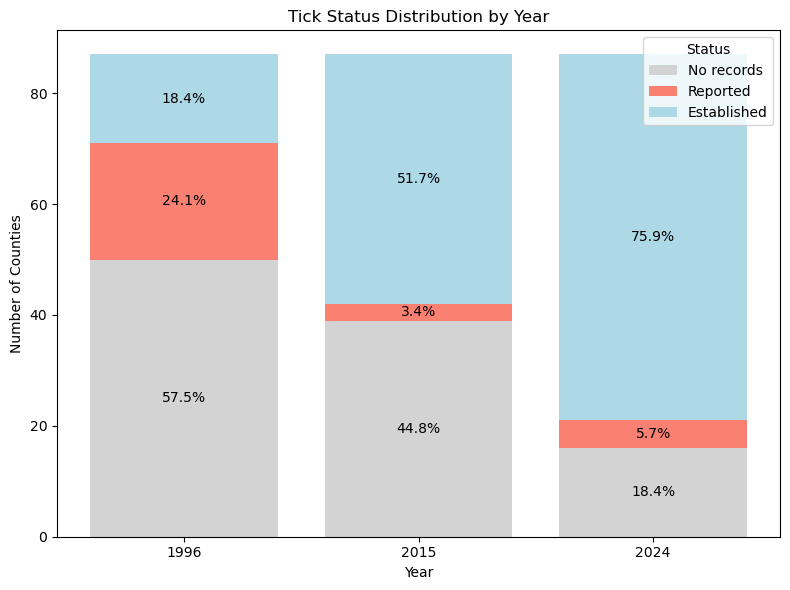

In [122]:
# Recalculate percent table (just to be safe)
percent_table = summary_table.div(summary_table.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,6))

x = range(len(summary_table.index))
colors = ['lightgrey', 'salmon', 'lightblue']

bottom = [0] * len(summary_table.index)

for i, status in enumerate(summary_table.columns):
    values = summary_table[status].values
    percents = percent_table[status].values
    
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=colors[i],
        label=status
    )
    
    # Add percent labels centered in each segment
    for j in range(len(values)):
        if values[j] > 0:  # avoid labeling zero segments
            ax.text(
                x[j],
                bottom[j] + values[j]/2,
                f"{percents[j]:.1f}%",
                ha='center',
                va='center',
                fontsize=10,
                color='black'
            )
    
    # Update bottom stack
    bottom = [bottom[j] + values[j] for j in range(len(values))]

ax.set_xticks(x)
ax.set_xticklabels(summary_table.index)

ax.set_ylabel("Number of Counties")
ax.set_xlabel("Year")
ax.set_title("Tick Status Distribution by Year")
ax.legend(title="Status")

plt.tight_layout()
plt.savefig("Tick_Status_Bar_Chart.png", dpi=300)
plt.show()

In [124]:
counties = gpd.read_file("tl_2025_us_county/tl_2025_us_county.shp")
counties = counties[['NAME','STATEFP','geometry']].rename(columns={'NAME':'county_name'})
# Filter to Minnesota
counties = counties[counties['STATEFP']=='27']  # MN
counties = counties.to_crs("EPSG:4326")

In [172]:

gdf_map = counties.merge(
    df_merged[['COUNTY', 'VALUE_1996', 'VALUE_2015', 'VALUE_2024']],
    left_on='county_name',
    right_on='COUNTY',
    how='left'
)

In [156]:
# Define the mapping from numeric status → color
status_colors = {0:'lightgrey', 1:'salmon', 2:'lightblue'}

# Map the numeric values to the color column
gdf_map['color'] = gdf_map['VALUE_2024'].map(status_colors)

# Check that color column is populated
print(gdf_map[['VALUE_2024','color']].head())

   VALUE_2024      color
0           2  lightblue
1           2  lightblue
2           2  lightblue
3           2  lightblue
4           0  lightgrey


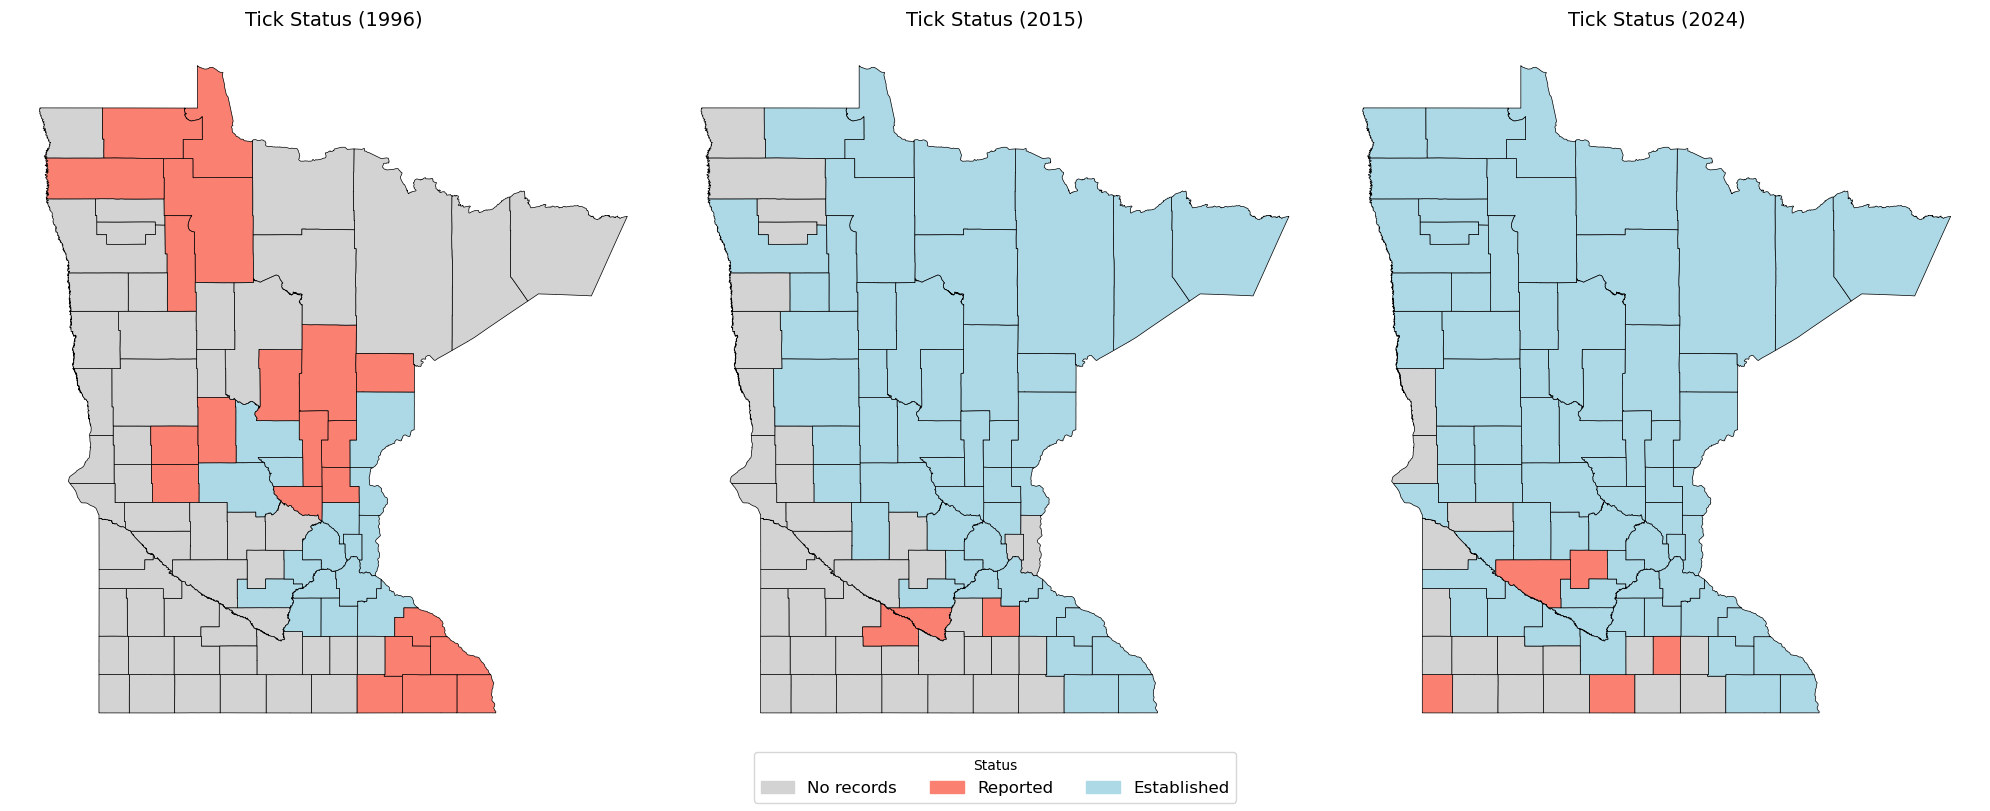

In [184]:
for year in ['VALUE_1996','VALUE_2015','VALUE_2024']:
    gdf_map[f'color_{year}'] = gdf_map[year].map(status_colors)

for year in ['VALUE_1996','VALUE_2015','VALUE_2024']:
    gdf_map[f'color_{year}'] = gdf_map[year].map(status_colors)

years = ['VALUE_1996','VALUE_2015','VALUE_2024']
fig, axes = plt.subplots(1, 3, figsize=(20,8))

for ax, year in zip(axes, years):
    gdf_map.plot(
        color=gdf_map[f'color_{year}'],
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    ax.set_title(f"Tick Status ({year[-4:]})", fontsize=14)
    ax.axis('off')

# Create legend using the string labels
legend_patches = [mpatches.Patch(color=status_colors[k], label=status_labels[k]) for k in status_colors]
fig.legend(handles=legend_patches, title="Status", loc='lower center', ncol=3, fontsize=12)

plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig("Tick_Status_mn_Map.png")
plt.show()

Tick-Borne Disease Data

In [803]:
# Disease reporting changes over the years, it is important to examine the missing data
print(tbd.info())
print(tbd.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 5 to 319
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             27 non-null     float64
 1   State                            27 non-null     object 
 2   Total Population (in thousands)  26 non-null     float64
 3   Anaplasmosis                     14 non-null     object 
 4   Ehrlichiosis                     23 non-null     object 
 5   Undetermined E/A                 14 non-null     object 
 6   Babesiosis                       11 non-null     object 
 7   Lyme disease                     26 non-null     float64
dtypes: float64(3), object(5)
memory usage: 1.9+ KB
None
Year                                0
State                               0
Total Population (in thousands)     1
Anaplasmosis                       13
Ehrlichiosis                        4
Undetermined E/A                   

In [435]:
# List of diseases
diseases = ['Anaplasmosis','Ehrlichiosis','Undetermined E/A','Babesiosis','Lyme disease']

# Ensure numeric
for col in diseases:
    tbd[col] = pd.to_numeric(tbd[col], errors='coerce')

# Add a rate column for each disease (cases per 100,000 population)
for col in diseases:
    # Only compute where both disease count and population are not NaN
    tbd[f'{col}_rate'] = tbd.apply(
        lambda row: (row[col] / (row['Total Population (in thousands)'] * 1000) * 100000) 
        if pd.notna(row[col]) and pd.notna(row['Total Population (in thousands)']) else pd.NA,
        axis=1
    )

# Inspect
tbd.head()

,Year,State,Total Population (in thousands),Anaplasmosis,Ehrlichiosis,Undetermined E/A,Babesiosis,Lyme disease,Anaplasmosis_rate,Ehrlichiosis_rate,Undetermined E/A_rate,Babesiosis_rate,Lyme disease_rate
5,1996.0,MN,4658.0,NaN,NaN,NaN,NaN,251.0,<NA>,<NA>,<NA>,<NA>,5.388579
17,1997.0,MN,4686.0,NaN,NaN,NaN,NaN,256.0,<NA>,<NA>,<NA>,<NA>,5.463082
29,1998.0,MN,4725.0,NaN,NaN,NaN,NaN,261.0,<NA>,<NA>,<NA>,<NA>,5.52381
41,1999.0,MN,4776.0,NaN,0.0,NaN,NaN,283.0,<NA>,0.0,<NA>,<NA>,5.925461
53,2000.0,MN,4776.0,NaN,83.0,NaN,NaN,465.0,<NA>,1.737856,<NA>,<NA>,9.736181


In [1205]:
naTable = tbd.isna().sum()
naTable.to_csv('table2AnaTBD.csv')

This is excpected. Minnesota did not start reporting cases of non lyme until ... 2020 minnesota did not report any diseases. also in 2017 CDC stacks is missing all of the table corresponding to diseases. 

In [443]:
# List of diseases
disease_rates = ['Anaplasmosis_rate','Ehrlichiosis_rate','Undetermined E/A_rate','Babesiosis_rate','Lyme disease_rate']

# Ensure numeric
for col in disease_rates:
    tbd[col] = pd.to_numeric(tbd[col], errors='coerce')

# Descriptive stats for counts (ignores NaNs automatically)
desc_counts = tbd[disease_rates].describe()  # count, mean, std, min, 25%, 50%, 75%, max

desc_counts.to_csv('summary_by_rate.csv')


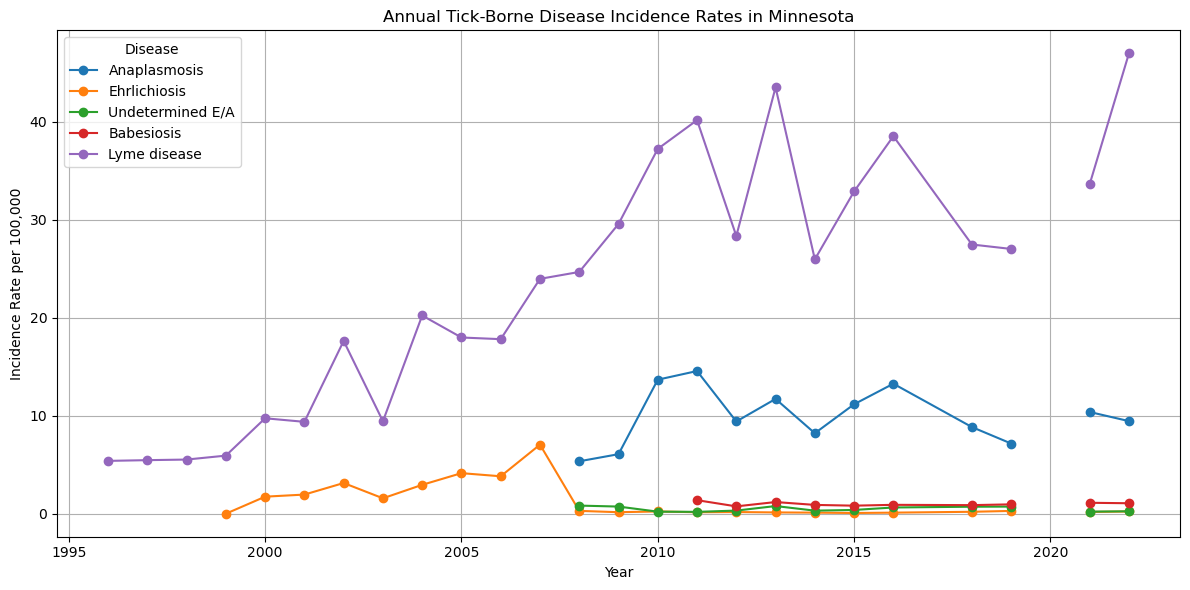

In [453]:
# List of diseases and their rate columns
diseases = ['Anaplasmosis','Ehrlichiosis','Undetermined E/A','Babesiosis','Lyme disease']
rate_cols = [f'{d}_rate' for d in diseases]

# Set up plot
plt.figure(figsize=(12,6))

# Plot each disease
for disease, col in zip(diseases, rate_cols):
    plt.plot(tbd['Year'], tbd[col], marker='o', label=disease)

# Labels and title
plt.xlabel('Year')
plt.ylabel('Incidence Rate per 100,000')
plt.title('Annual Tick-Borne Disease Incidence Rates in Minnesota')
plt.legend(title='Disease')
plt.grid(True)
plt.tight_layout()
plt.savefig('rates_line.png')
plt.show()

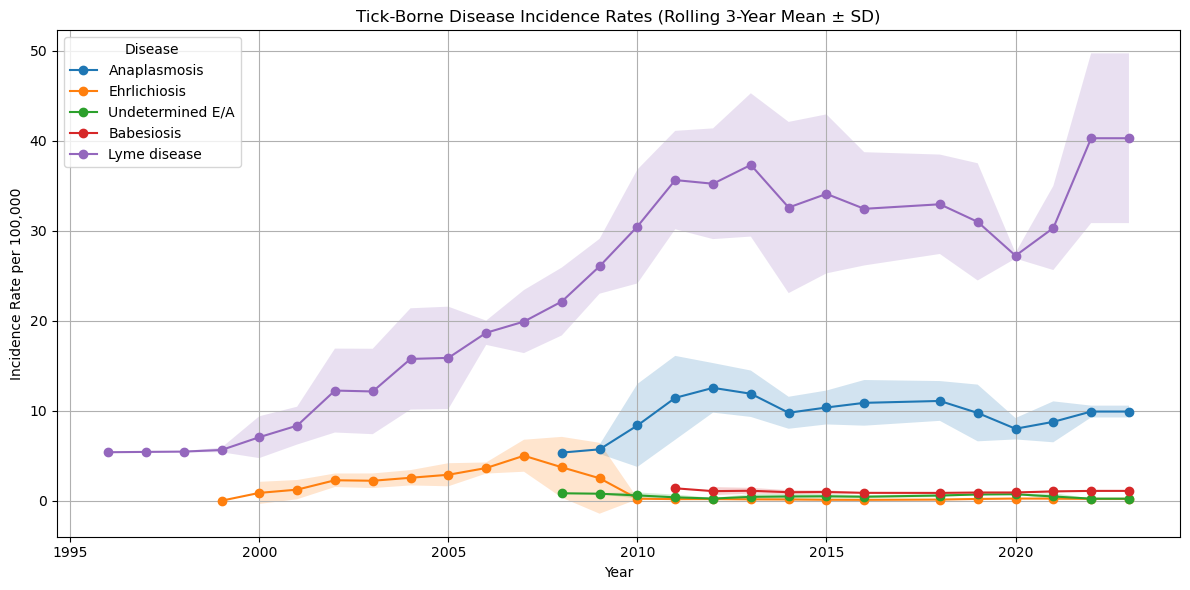

In [461]:
# List of diseases and rate columns
diseases = ['Anaplasmosis','Ehrlichiosis','Undetermined E/A','Babesiosis','Lyme disease']
rate_cols = [f'{d}_rate' for d in diseases]

# Optional: compute rolling mean & std (3-year window)
rolling_window = 3

plt.figure(figsize=(12,6))

for disease, col in zip(diseases, rate_cols):
    # Compute rolling mean and std (skip NaNs)
    rolling_mean = tbd[col].rolling(window=rolling_window, min_periods=1).mean()
    rolling_std = tbd[col].rolling(window=rolling_window, min_periods=1).std()
    
    # Plot rolling mean
    plt.plot(tbd['Year'], rolling_mean, marker='o', label=disease)
    
    # Fill ±1 std
    plt.fill_between(
        tbd['Year'], 
        rolling_mean - rolling_std, 
        rolling_mean + rolling_std, 
        alpha=0.2
    )

plt.xlabel('Year')
plt.ylabel('Incidence Rate per 100,000')
plt.title(f'Tick-Borne Disease Incidence Rates (Rolling {rolling_window}-Year Mean ± SD)')
plt.legend(title='Disease')
plt.grid(True)
plt.tight_layout()
plt.savefig('rates_line.png')
plt.show()

Historical Weather 

In [232]:

variables = ['EMNT','EMSD','TAVG','TMIN','TMAX','SNOW','DT00','DSND']

# Basic descriptive statistics
desc = county_df[variables].describe().T

# NA counts
na_counts = county_df[variables].isna().sum()

# Add NA row
desc['NA_sum'] = na_counts

# Reorder columns
summary_table = desc[['count','NA_sum','mean','std','min','25%','50%','75%','max']]

summary_table=summary_table.T

In [1215]:
summary_table.to_csv('weatherSummary.csv')

In [234]:
summary_table.head()

,EMNT,EMSD,TAVG,TMIN,TMAX,SNOW,DT00,DSND
count,11798.000000,9820.000000,11715.000000,11798.000000,11773.000000,11311.000000,11798.000000,9820.000000
NA_sum,482.000000,2460.000000,565.000000,482.000000,507.000000,969.000000,482.000000,2460.000000
mean,-23.541831,224.876551,-5.891112,-11.021836,-0.770361,206.404986,7.287709,17.947085
std,7.250855,195.472361,5.681046,5.890550,5.629964,172.111395,6.779506,11.276923
min,-47.200000,0.000000,-22.450000,-29.266667,-16.900000,0.000000,0.000000,0.000000


In [1015]:
# Is winter variablility changing
county_df.groupby('YEAR')['TMIN'].std()

YEAR
1995    4.517745
1996    4.848759
1997    5.251809
1998    4.214902
1999    5.409166
2000    6.909584
2001    6.751265
2002    2.787537
2003    4.841562
2004    6.179203
2005    4.948019
2006    4.281502
2007    5.818546
2008    6.063862
2009    7.382330
2010    6.158815
2011    5.672357
2012    5.187337
2013    4.657475
2014    6.061436
2015    6.688474
2016    6.052775
2017    3.819433
2018    5.152496
2019    5.485580
2020    5.260846
2021    6.008160
2022    6.978254
2023    5.061953
2024    3.771717
2025    6.406888
2026    2.462929
Name: TMIN, dtype: float64

CMIP6 data

In [1020]:
historical_weather.describe()

,YEAR,MONTH,TMIN,TMAX,pr,SNOW
count,22790.000000,22790.000000,22790.000000,22790.000000,22790.000000,22790.000000
mean,2014.150943,5.800000,-10.186358,0.275390,29.432589,21.068712
std,8.673281,4.707544,5.667245,5.031482,19.129648,14.105032
min,1995.000000,1.000000,-26.812500,-14.873125,0.000000,0.000000
25%,2008.000000,2.000000,-14.722499,-3.520000,14.941924,10.481190
50%,2017.000000,3.000000,-10.020000,-0.095000,24.857450,17.802668
75%,2021.000000,11.000000,-5.405000,4.486500,40.041952,28.483754
max,2025.000000,12.000000,2.770000,12.626667,139.975479,115.299294


In [355]:
historical_weather = pd.read_csv('HistoricalWeather.csv')

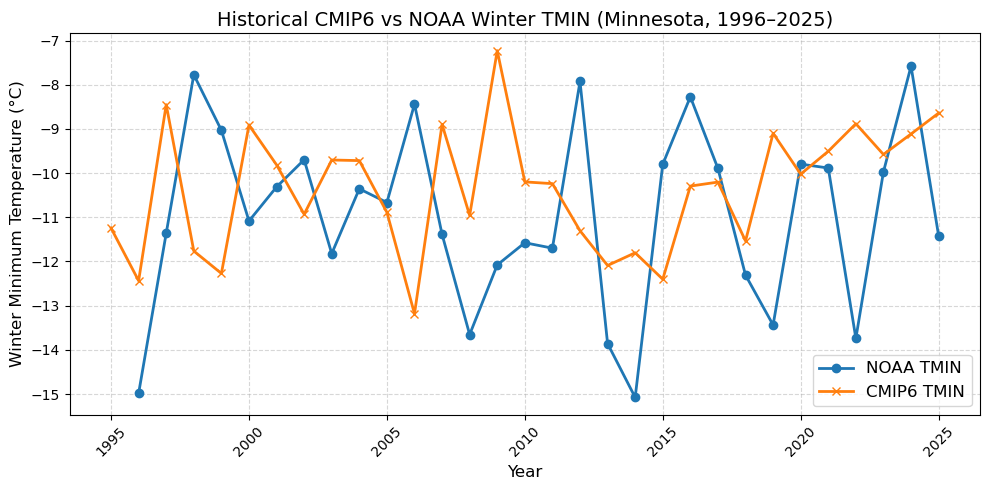

In [359]:
# Compute county-level winter mean for NOAA
import matplotlib.pyplot as plt

# Subset and aggregate
df_noaa_hist = county_df[county_df['YEAR'].between(1996, 2025)]
noaa_mean = df_noaa_hist.groupby('YEAR')['TMIN'].mean()
cmip_mean = historical_weather.groupby('YEAR')['TMIN'].mean()

# Plot
plt.figure(figsize=(10,5))

plt.plot(noaa_mean.index, noaa_mean, label='NOAA TMIN', marker='o', color='tab:blue', linewidth=2)
plt.plot(cmip_mean.index, cmip_mean, label='CMIP6 TMIN', marker='x', color='tab:orange', linewidth=2)

# Labels, title, legend
plt.xlabel('Year', fontsize=12)
plt.ylabel('Winter Minimum Temperature (°C)', fontsize=12)
plt.title('Historical CMIP6 vs NOAA Winter TMIN (Minnesota, 1996–2025)', fontsize=14)
plt.legend(fontsize=12)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: make x-axis ticks readable
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('CMIP6vnoaa.png')
plt.show()

In [1032]:
diff = cmip_mean - noaa_mean
diff.describe()

count    19.000000
mean      0.630910
std       2.728287
min      -4.742941
25%      -0.728222
50%       1.460074
75%       2.517578
max       4.849209
Name: TMIN, dtype: float64

In [1061]:
# Tick climate relationship
tick_climate = county_df.merge(
    df_ticks_long[['COUNTY','YEAR','STATUS', 'VALUE']],
    on=['COUNTY','YEAR'],
    how='inner'
)


In [1063]:
tick_climate.head()

,COUNTY,YEAR,MONTH,EMNT,EMSD,TAVG,TMIN,TMAX,SNOW,DT00,DSND,extreme_cold,harsh_uninsulated,STATUS,VALUE
0,Aitkin,1996,2,-41.950000,355.5,-12.400000,-18.800000,-5.666667,201.500000,11.500000,14.5,True,False,Reported,1
1,Aitkin,1996,3,-29.033333,686.0,-7.966667,-14.400000,-1.566667,270.000000,11.000000,28.0,True,False,Reported,1
2,Aitkin,1996,11,-23.050000,NaN,-6.100000,-10.350000,-1.850000,235.333333,3.500000,NaN,True,False,Reported,1
3,Aitkin,1996,12,-31.100000,NaN,-12.600000,-16.400000,-8.850000,356.000000,14.500000,NaN,True,False,Reported,1
4,Aitkin,2016,1,-30.000000,279.0,-11.100000,-15.466667,-6.833333,194.000000,9.333333,30.0,True,False,Established,2


In [1191]:
tick_climate.groupby('STATUS')[['TMIN','EMNT','DT00','SNOW']].mean()


,TMIN,EMNT,DT00,SNOW
STATUS,,,,
Established,-8.786505,-22.848662,5.143695,186.243619
No records,-11.260845,-26.013690,8.101364,243.839032
Reported,-14.381812,-30.497826,10.602174,248.593860


In [1167]:
tick_climate['established_binary'] = (tick_climate['VALUE'] == 2).astype(int)
status_labels_bin = {0: 'Not Established', 1: 'Established'}
tick_climate['status_label_bin'] = tick_climate['established_binary'].map(status_labels_bin)

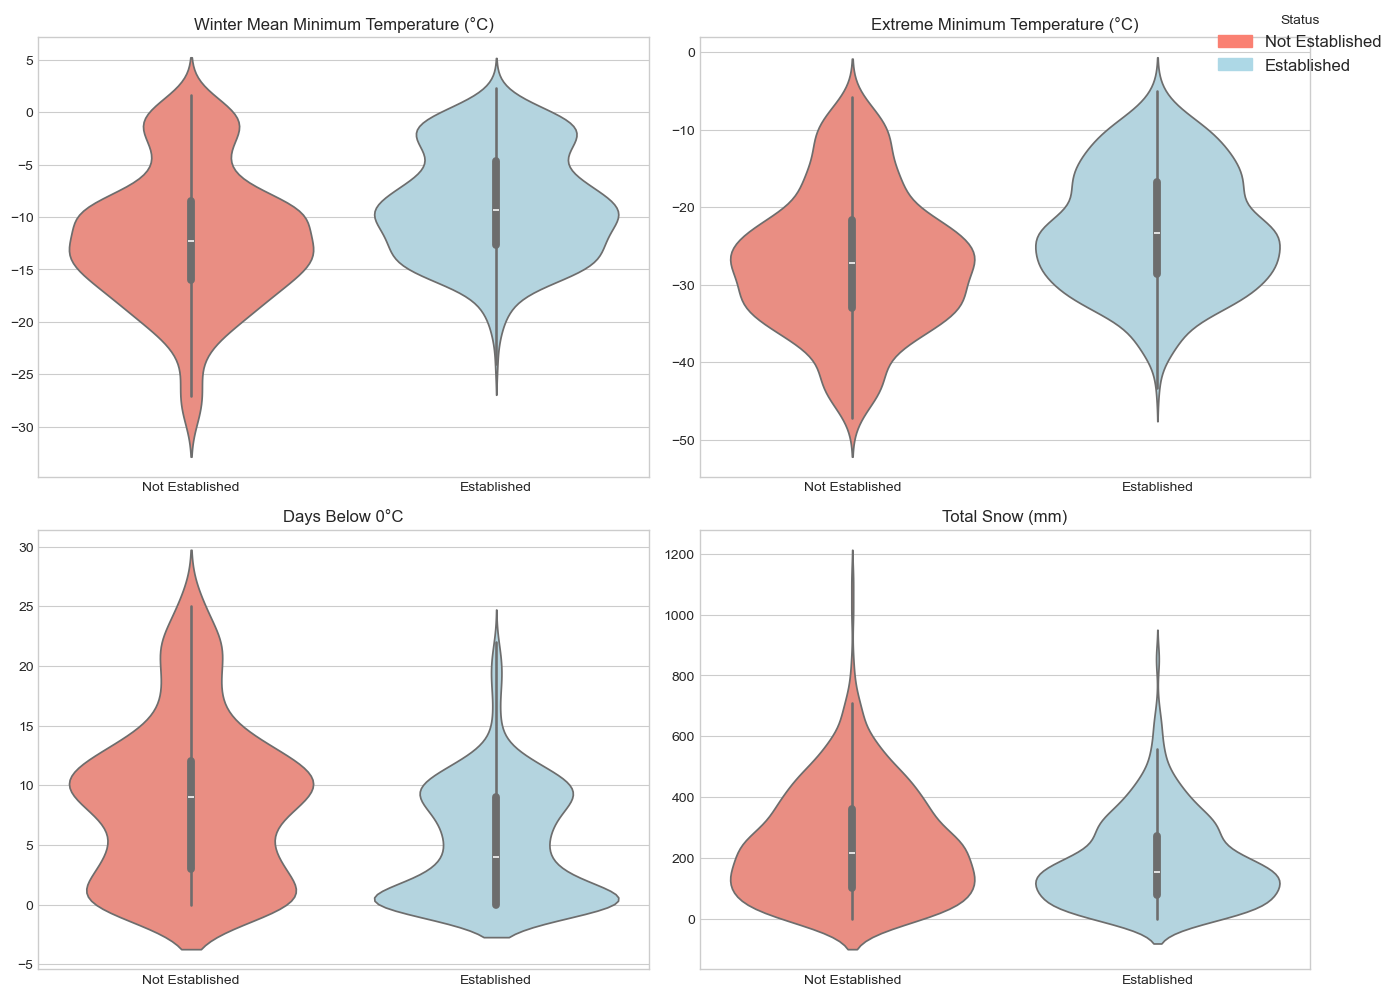

In [1193]:
# Violin Plot

fig, axes = plt.subplots(2, 2, figsize=(14,10))

variables = ['TMIN', 'EMNT', 'DT00', 'SNOW']
titles = [
    "Winter Mean Minimum Temperature (°C)",
    "Extreme Minimum Temperature (°C)",
    "Days Below 0°C",
    "Total Snow (mm)"
]

palette = ['salmon','lightblue']

for ax, var, title in zip(axes.flatten(), variables, titles):
    sns.violinplot(
        x='status_label_bin',
        y=var,
        hue='status_label_bin',
        data=tick_climate,
        inner='box',
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

from matplotlib.patches import Patch

handles = [Patch(color=palette[i], label=list(status_labels_bin.values())[i]) for i in range(2)]
fig.legend(handles=handles, title='Status', loc='upper right', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig("Tick_Climate_Violin.png", dpi=300, bbox_inches='tight')
plt.show()



In [1126]:
tick_climate.isna().sum()

COUNTY                 0
YEAR                   0
MONTH                  0
EMNT                  46
EMSD                 229
TAVG                  53
TMIN                  46
TMAX                  47
SNOW                  78
DT00                  46
DSND                 229
extreme_cold           0
harsh_uninsulated      0
STATUS                 0
VALUE                  0
status_label           0
dtype: int64

In [1177]:
groups = [
    tick_climate[tick_climate['established_binary']==0]['TMIN'].dropna(),
    tick_climate[tick_climate['established_binary']==1]['TMIN'].dropna()
]

f_oneway(*groups)


F_onewayResult(statistic=79.96295247299227, pvalue=1.566816541684175e-18)

In [1179]:
groups = [
    tick_climate[tick_climate['established_binary']==0]['DT00'].dropna(),
    tick_climate[tick_climate['established_binary']==1]['DT00'].dropna()
]

f_oneway(*groups)

F_onewayResult(statistic=99.12313250053397, pvalue=2.011589543308914e-22)

In [1181]:
groups = [
    tick_climate[tick_climate['established_binary']==0]['SNOW'].dropna(),
    tick_climate[tick_climate['established_binary']==1]['SNOW'].dropna()
]

f_oneway(*groups)

F_onewayResult(statistic=35.03126008687192, pvalue=4.358640882408901e-09)

In [1183]:
groups = [
    tick_climate[tick_climate['established_binary']==0]['EMNT'].dropna(),
    tick_climate[tick_climate['established_binary']==1]['EMNT'].dropna()
]

f_oneway(*groups)

F_onewayResult(statistic=67.4253411551216, pvalue=6.045097087427385e-16)

In [1150]:
def eta_squared(df, var, group_col = 'established'):
    
    grand_mean = df[var].mean(skipna=True)
    valid_groups = [
        g for _, g in df.groupby(group_col)
        if g[var].dropna().size > 1
    ]
    ss_between = sum(len(g) * ((g[var].mean() - grand_mean)**2) for g in valid_groups)
    ss_total = sum((df[var].dropna() - grand_mean)**2)
    
    if ss_total == 0:
        return np.nan  # Prevent division by zero
    
    return ss_between / ss_total

variables = ['TMIN', 'SNOW', 'EMNT', 'DT00']

tick_climate['established'] = (tick_climate['VALUE']==2).astype(int)
for var in variables:
    eta = eta_squared(tick_climate, var, group_col='established')
    print(f"{var}: eta-squared = {eta:.3f}")


TMIN: eta-squared = 0.070
SNOW: eta-squared = 0.034
EMNT: eta-squared = 0.060
DT00: eta-squared = 0.086


In [1203]:
cl = 0.95
def conf(var):
    for group, g in tick_climate.groupby('established_binary'):
        values = g[var].dropna()
        n = len(values)
    
        mean = np.mean(values)
        se = np.std(values, ddof=1) / np.sqrt(n)
    
        ci = stats.t.interval(cl, df=n-1, loc=mean, scale=se)
    return ci

vars = ['EMNT', 'DT00', 'SNOW']
for var in vars:
    conf(var)
    print(var, conf(var))

EMNT (-23.488997873932217, -22.20832681324192)
DT00 (4.73950592920458, 5.547884448058061)
SNOW (173.92367944961816, 198.56355826504816)


In [1187]:
tick_climate.groupby('status_label_bin')['TMIN'].quantile([0.25, 0.5, 0.75])

status_label_bin      
Established       0.25   -12.70
                  0.50    -9.30
                  0.75    -4.65
Not Established   0.25   -16.00
                  0.50   -12.30
                  0.75    -8.50
Name: TMIN, dtype: float64

In [1189]:

established = tick_climate[tick_climate['established_binary']==1].dropna()
pearsonr(established['TMIN'], established['SNOW'])


PearsonRResult(statistic=-0.37187364361441866, pvalue=4.838437584676303e-16)